# 2D Gravity Inversion

## Bayesian Inversion for Subsurface Density Estimation

This notebook demonstrates solving a 2D gravity inverse problem using Bayesian estimation.

### Problem Setup

**State (x):** Density anomalies in subsurface prisms [g/cm³]  
**Observations (z):** Vertical component of gravity field at surface [mGal]  
**Forward model:** z = H @ x (Newtonian gravity from rectangular prisms)

### Geometry
- **Domain:** 100m horizontal × 40m depth
- **Mesh:** 10 × 4 prisms (horizontal × vertical)
- **Observations:** 41 surface gravity measurements

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable

from fips import Block, CovarianceMatrix, ForwardOperator, InverseProblem, Vector

# Configure plotting
plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

## Configuration

In [2]:
# Physical constant
GAMMA = 6.67e-4  # Gravitational constant in CGS units

## Define Geometry and Generate Synthetic Data

In [3]:
# Observed gravity anomalies
z_obs = np.array(
    [
        6.5112333e-03,
        7.1144759e-03,
        7.8050213e-03,
        8.6004187e-03,
        9.5228049e-03,
        1.0600394e-02,
        1.1869543e-02,
        1.3377636e-02,
        1.5187140e-02,
        1.7381291e-02,
        2.0071869e-02,
        2.3409173e-02,
        2.7592423e-02,
        3.2872699e-02,
        3.9524661e-02,
        4.7739666e-02,
        5.7427097e-02,
        6.8126652e-02,
        7.9261565e-02,
        9.0330964e-02,
        1.0070638e-01,
        1.0950167e-01,
        1.1588202e-01,
        1.1936106e-01,
        1.1961197e-01,
        1.1617789e-01,
        1.0868957e-01,
        9.7370419e-02,
        8.3429883e-02,
        6.9002570e-02,
        5.6079733e-02,
        4.5525921e-02,
        3.7267881e-02,
        3.0880404e-02,
        2.5919366e-02,
        2.2024198e-02,
        1.8925481e-02,
        1.6427182e-02,
        1.4387142e-02,
        1.2701558e-02,
        1.1293783e-02,
    ]
)

# Create observation locations (41 points from 0 to 1000 m)
obs_locs = np.linspace(0, 1000, len(z_obs))

# Create mesh boundaries (10 x 4 prisms)
prism_x = np.linspace(0, 1000, 11)  # 11 boundaries for 10 prisms
prism_z = np.linspace(25, 250, 5)  # 5 boundaries for 4 prisms

n_obs = len(z_obs)
n_x = len(prism_x) - 1
n_z = len(prism_z) - 1
n_state = n_x * n_z

print("Data created:")
print(f"  Observations: {n_obs}")
print(f"  State dimension: {n_state} ({n_x} × {n_z} prisms)")
print(f"  Gravity range: [{z_obs.min():.4f}, {z_obs.max():.4f}] mGal")
print(
    f"  Domain: {prism_x.min()}-{prism_x.max()} m (horizontal), {prism_z.min()}-{prism_z.max()} m (depth)"
)

Data created:
  Observations: 41
  State dimension: 40 (10 × 4 prisms)
  Gravity range: [0.0065, 0.1196] mGal
  Domain: 0.0-1000.0 m (horizontal), 25.0-250.0 m (depth)


## Build Forward Operator

In [4]:
def gravity_integral(x, z):
    """
    Analytical integral for Newtonian gravity from a rectangular prism.

    Parameters
    ----------
    x, z : array_like
        Horizontal and vertical distances

    Returns
    -------
    array_like
        Integrated gravity contribution
    """
    return z * np.arctan(x / z) + x / 2 * np.log(z**2 + x**2)


def build_forward_operator(obs_locs, prism_x, prism_z, gamma=GAMMA):
    """
    Build forward operator H relating density to gravity.

    Maps state (density in prisms) to observations (gravity at surface):
        z = H @ x

    Parameters
    ----------
    obs_locs : array
        Observation locations (horizontal positions) [m]
    prism_x : array
        Prism boundaries in x-direction [m]
    prism_z : array
        Prism boundaries in z-direction (depth) [m]
    gamma : float
        Gravitational constant

    Returns
    -------
    H : ndarray
        Forward operator [n_obs × n_state]
    """
    n_obs = len(obs_locs)
    n_x = len(prism_x) - 1
    n_z = len(prism_z) - 1
    n_state = n_x * n_z

    H = np.zeros((n_obs, n_state))

    idx = 0
    for ix in range(1, len(prism_x)):
        x1 = prism_x[ix - 1] - obs_locs  # Lower x boundary
        x2 = prism_x[ix] - obs_locs  # Upper x boundary

        for iz in range(1, len(prism_z)):
            z1 = prism_z[iz - 1]  # Upper z boundary (shallow)
            z2 = prism_z[iz]  # Lower z boundary (deep)

            # Compute gravity contribution using analytical formula
            contrib = (
                gravity_integral(x2, z2)
                - gravity_integral(x2, z1)
                - gravity_integral(x1, z2)
                + gravity_integral(x1, z1)
            )

            H[:, idx] = 2 * gamma * contrib
            idx += 1

    return H

In [5]:
# Build forward operator
print("Building forward operator...")
H = build_forward_operator(obs_locs, prism_x, prism_z)

print(f"Forward operator shape: {H.shape}")
print(f"  Condition number: {np.linalg.cond(H):.2e}")

Building forward operator...
Forward operator shape: (41, 40)
  Condition number: 5.38e+07


## Setup Inverse Problem

### Prior Information
- **Mean:** x₀ = 0 (zero density anomaly)
- **Covariance:** S_0 = 0.5² I (independent prisms)

### Observation Error
- S_z = (0.05 · max(z))² I (5% of maximum signal)

### Bayesian Framework
**Posterior estimate:**
$$\hat{x} = x_0 + K(z - Hx_0)$$

**Posterior covariance:**
$$\hat{S} = S_0 - (HS_0)^T(HS_0H^T + S_z)^{-1}(HS_0)$$

In [6]:
# Create indices
obs_idx = pd.Index([f"obs_{i:03d}" for i in range(n_obs)], name="x")
state_idx = pd.Index([f"prism_{i:03d}" for i in range(n_state)], name="prism")

# Observation vector
z = Vector(
    name="observations", data=[Block(pd.Series(z_obs, index=obs_idx, name="gravity"))]
)

# Prior state (zero density anomaly)
x_0 = Vector(
    name="prior",
    data=[Block(pd.Series(np.zeros(n_state), index=state_idx, name="density"))],
)

# Prior error covariance (independent prisms)
sigma_x = 0.5  # Prior uncertainty [g/cm³]
S_0 = CovarianceMatrix(
    pd.DataFrame(
        np.diag(sigma_x**2 * np.ones(n_state)), index=x_0.index, columns=x_0.index
    )
)

# Observation error covariance
sigma_z = 0.05 * np.max(z_obs)  # 5% of max signal
S_z = CovarianceMatrix(
    pd.DataFrame(np.diag(sigma_z**2 * np.ones(n_obs)), index=z.index, columns=z.index)
)

# Forward operator
H_mat = ForwardOperator(pd.DataFrame(H, index=z.index, columns=x_0.index))

# Create problem
problem = InverseProblem(
    prior=x_0, obs=z, forward_operator=H_mat, prior_error=S_0, modeldata_mismatch=S_z
)

print("Inverse problem configured.")
print(f"  Prior uncertainty: {sigma_x} g/cm³")
print(f"  Observation uncertainty: {sigma_z:.4f} mGal")

Inverse problem configured.
  Prior uncertainty: 0.5 g/cm³
  Observation uncertainty: 0.0060 mGal


## Solve Problem

In [7]:
# Solve using Bayesian estimator
print("Solving...")
problem.solve(estimator="bayesian")
print("✓ Solution complete")

Solving...
✓ Solution complete


## Diagnostics

Analyze the solution quality and information content.

In [8]:
# Extract results
x_post = problem.posterior.data.values
z_obs_vals = problem.obs.data.values
z_post = problem.posterior_obs.data.values
z_prior = problem.prior_obs.data.values

# Posterior state
print("POSTERIOR STATE (DENSITY)")
print(f"  Mean: {x_post.mean():.4f} g/cm³")
print(f"  Std:  {x_post.std():.4f} g/cm³")
print(f"  Range: [{x_post.min():.4f}, {x_post.max():.4f}] g/cm³")

# Observation fit
print("\nOBSERVATION FIT")
print(f"  RMSE: {problem.estimator.RMSE:.6e} mGal")
print(f"  R²: {problem.estimator.R2:.4f}")
residuals = z_obs_vals - z_post
print(f"  Max residual: {np.abs(residuals).max():.6e} mGal")

# Uncertainty reduction
prior_std = np.sqrt(np.diag(problem.prior_error.values))
post_std = np.sqrt(np.diag(problem.posterior_error.values))
reduction = (1 - post_std / prior_std) * 100

print("\nUNCERTAINTY REDUCTION")
print(f"  Mean: {reduction.mean():.1f}%")
print(f"  Range: [{reduction.min():.1f}%, {reduction.max():.1f}%]")

# Information content
print("\nINFORMATION CONTENT")
print(f"  DOFS: {problem.estimator.DOFS:.1f}")
print(f"  Reduced χ²: {problem.estimator.reduced_chi2:.3f}")

POSTERIOR STATE (DENSITY)
  Mean: 0.0609 g/cm³
  Std:  0.0931 g/cm³
  Range: [-0.0185, 0.3153] g/cm³

OBSERVATION FIT
  RMSE: 4.625043e-04 mGal
  R²: 0.9999
  Max residual: 1.205564e-03 mGal

UNCERTAINTY REDUCTION
  Mean: 18.9%
  Range: [2.0%, 59.1%]

INFORMATION CONTENT
  DOFS: 12.0
  Reduced χ²: 0.054


## Visualization

### Data Fit

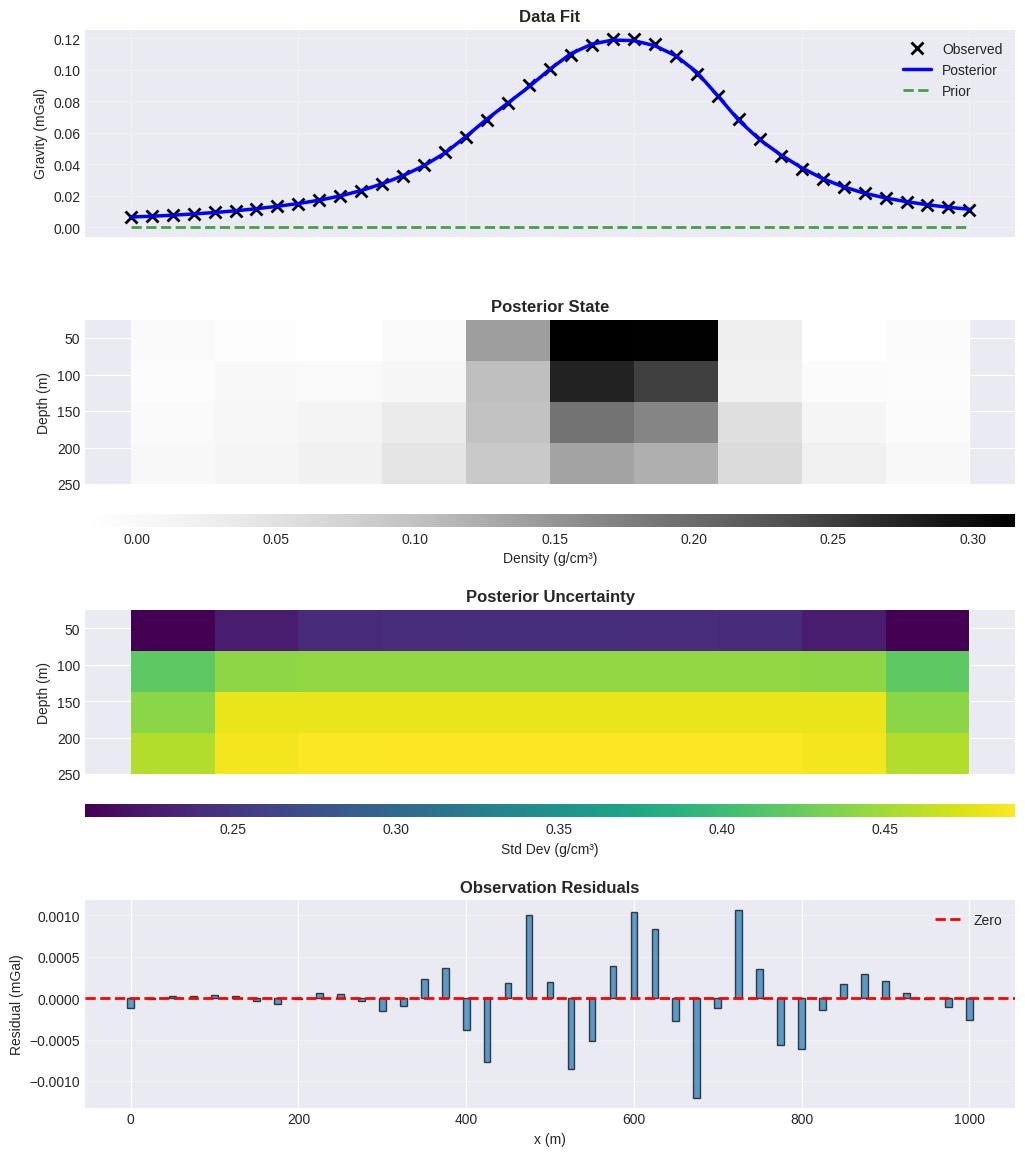

In [9]:
# Combined visualization: all plots with shared x-axis
fig, axes = plt.subplots(
    4, 1, figsize=(12, 14), sharex=True, gridspec_kw={"hspace": 0.4}
)

# Prepare data for pcolormesh plots
x_post_2d = x_post.reshape(n_x, n_z).T
x_post_std = np.sqrt(np.diag(problem.posterior_error.values))
x_post_std_2d = x_post_std.reshape(n_x, n_z).T
X, Z = np.meshgrid(prism_x, prism_z)

# Plot 1: Data fit
ax = axes[0]
ax.plot(obs_locs, z_obs_vals, "kx", label="Observed", markersize=8, markeredgewidth=2)
ax.plot(obs_locs, z_post, "b-", label="Posterior", linewidth=2.5)
ax.plot(obs_locs, z_prior, "g--", label="Prior", linewidth=2, alpha=0.7)
ax.set(ylabel="Gravity (mGal)")
ax.set_title("Data Fit", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Posterior density
ax = axes[1]
im1 = ax.pcolormesh(X, Z, x_post_2d, cmap="Greys", shading="flat")
ax.set(ylabel="Depth (m)")
ax.set_title("Posterior State", fontweight="bold", fontsize=12)
ax.invert_yaxis()
cax1 = make_axes_locatable(ax).append_axes("bottom", size="8%", pad=0.3)
cbar1 = plt.colorbar(im1, cax=cax1, orientation="horizontal")
cbar1.set_label("Density (g/cm³)", fontsize=10)

# Plot 3: Posterior uncertainty
ax = axes[2]
im2 = ax.pcolormesh(X, Z, x_post_std_2d, cmap="viridis", shading="flat")
ax.set(ylabel="Depth (m)")
ax.set_title("Posterior Uncertainty", fontweight="bold", fontsize=12)
ax.invert_yaxis()
cax2 = make_axes_locatable(ax).append_axes("bottom", size="8%", pad=0.3)
cbar2 = plt.colorbar(im2, cax=cax2, orientation="horizontal")
cbar2.set_label("Std Dev (g/cm³)", fontsize=10)

# Plot 4: Residuals
ax = axes[3]
residuals = z_obs_vals - z_post
ax.bar(obs_locs, residuals, width=8, alpha=0.7, edgecolor="black")
ax.axhline(0, color="r", linestyle="--", linewidth=2, label="Zero")
ax.set(xlabel="x (m)", ylabel="Residual (mGal)")
ax.set_title("Observation Residuals", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.show()